<a href="https://colab.research.google.com/github/AmehQueenUnekwuojo/online-retail-sales-analysis/blob/main/PROJECT_2_Retail_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online Retail Sales Analysis

## Project Overview

This project analyzes the UCI Online Retail dataset to identify sales
patterns, customer behavior, product performance, market performance,
and seasonal trends.

The analysis uses Python, Pandas, and Matplotlib to clean, analyze,
and visualize the data and generate actionable business insights.

In [ ]:
!wget https://archive.ics.uci.edu/static/public/352/online+retail.zip

--2026-09-15 13:02:17--  https://archive.ics.uci.edu/static/public/352/online+retail.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘online+retail.zip’

online+retail.zip       [     <=>            ]  22.62M  25.1MB/s    in 0.9s    

2026-09-15 13:02:19 (25.1 MB/s) - ‘online+retail.zip’ saved [23715478]



In [ ]:
import zipfile

with zipfile.ZipFile("online+retail.zip", "r") as zip_ref:
    zip_ref.extractall()

In [ ]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

## 1. Dataset Overview

The dataset contains online retail transactions from a UK-based
non-store retailer between December 2010 and December 2011.

The dataset contains information on invoices, products, quantities,
prices, dates, customers, and countries.

In [ ]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [ ]:
print(df.shape)

(541909, 8)


In [ ]:
(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 2. Data Quality Investigation

The dataset was investigated for missing values, duplicate records,
cancelled transactions, negative quantities, and unusual prices.

In [ ]:
(df.describe())

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
print(df.isna().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
print(df.duplicated().sum())

5268


In [ ]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [ ]:
print(df["Country"].nunique())

38


In [ ]:
(df["Country"].value_counts().head(10))

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [ ]:
print(df["UnitPrice"].min())

-11062.06


In [ ]:
print(df["Quantity"].min())

-80995


In [ ]:
 (df[df["Quantity"]<0].head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [ ]:
(df[df["Quantity"]<0])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [ ]:
 (df [df["UnitPrice"]<0])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [ ]:
(df.loc[df["Quantity"]<0, "Description"].head())

,Description
141,Discount
154,SET OF 3 COLOURED FLYING DUCKS
235,PLASTERS IN TIN CIRCUS PARADE
236,PACK OF 12 PINK PAISLEY TISSUES
237,PACK OF 12 BLUE PAISLEY TISSUES


## 3. Data Cleaning

For the sales analysis, transactions with positive quantities were
retained in a separate dataframe called `sales_df`.

The original dataframe was preserved so that the raw data remained
available for reference.

In [ ]:
sales_df = df[df["Quantity"] > 0].copy()
(sales_df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
(sales_df.shape)

(531285, 8)

## 4. Business Metrics

In [ ]:
sales_df["Revenue"]=sales_df["UnitPrice"]*sales_df["Quantity"]
(sales_df["Revenue"])

,Revenue
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34
...,...
541904,10.20
541905,12.60
541906,16.60
541907,16.60


In [ ]:
print (sales_df["Revenue"].sum())

10644560.424


## 5. Country Analysis

In [ ]:
sales_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

,Revenue
Country,
United Kingdom,9003097.964
Netherlands,285446.340
EIRE,283453.960
Germany,228867.140
France,209715.110
Australia,138521.310
Spain,61577.110
Switzerland,57089.900
Belgium,41196.340


In [ ]:
(sales_df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [ ]:
sales_df.groupby("Country")["Revenue"]. sum ().sort_values(ascending=False)

,Revenue
Country,
United Kingdom,9003097.964
Netherlands,285446.340
EIRE,283453.960
Germany,228867.140
France,209715.110
Australia,138521.310
Spain,61577.110
Switzerland,57089.900
Belgium,41196.340


In [ ]:
import matplotlib.pyplot as plt

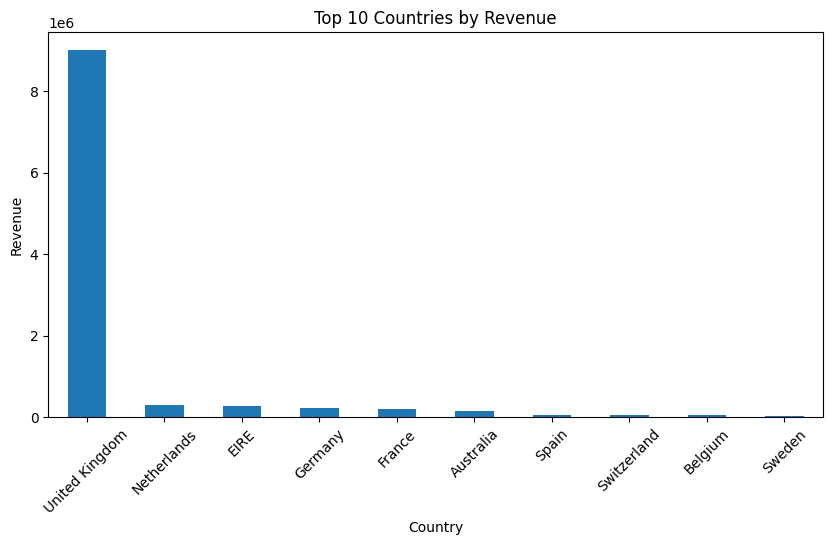

In [ ]:
country_revenue = sales_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

country_revenue.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## 6. Product Analysis

In [ ]:
(sales_df.groupby("Description")["Revenue"]. sum ().sort_values(ascending=False).head(10))

,Revenue
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174484.74
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106292.77
PARTY BUNTING,99504.33
JUMBO BAG RED RETROSPOT,94340.05
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
Manual,78112.82
POSTAGE,78101.88


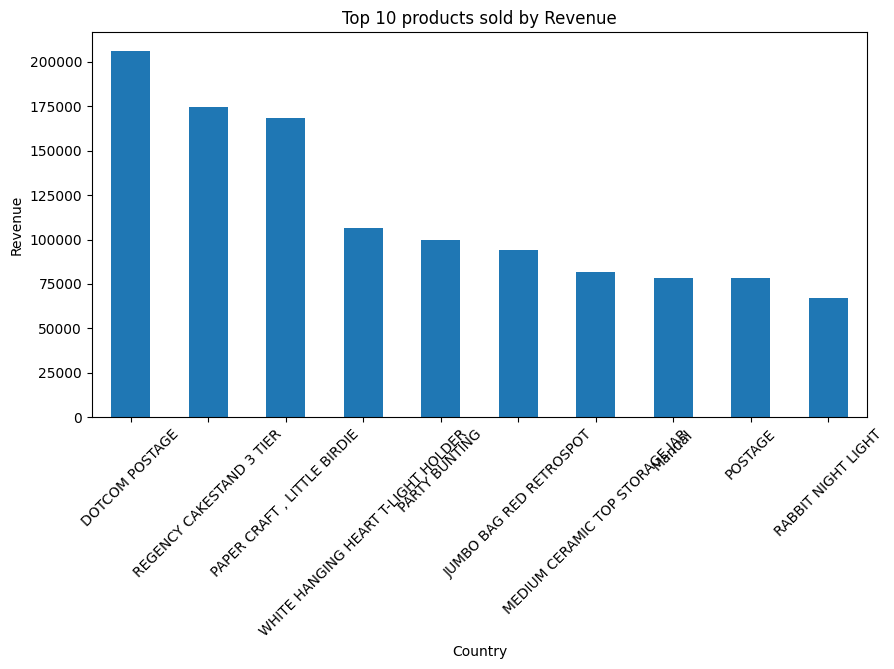

In [ ]:
product_revenue = sales_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

product_revenue.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 products sold by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
product_df = sales_df[
    ~sales_df["Description"].isin(["DOTCOM POSTAGE", "POSTAGE", "Manual"])
].copy()

In [ ]:
product_revenue = (
    product_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)
product_revenue

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,174484.74
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106292.77
PARTY BUNTING,99504.33
JUMBO BAG RED RETROSPOT,94340.05
...,...
Had been put aside.,0.00
wrongly marked 23343,0.00
wrongly marked,0.00


In [ ]:
non_products = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "Manual",
    "Discount",
    "Adjust bad debt"
]

product_df = sales_df[
    ~sales_df["Description"].isin(non_products)
].copy()

In [ ]:
product_revenue = (
    product_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,174484.74
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106292.77
PARTY BUNTING,99504.33
JUMBO BAG RED RETROSPOT,94340.05
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
RABBIT NIGHT LIGHT,66964.99
PAPER CHAIN KIT 50'S CHRISTMAS,64952.29
ASSORTED COLOUR BIRD ORNAMENT,59094.93


In [ ]:
product_quantity = product_df.groupby("Description")["Quantity"].sum()
(product_quantity)

,Quantity
Description,
4 PURPLE FLOCK DINNER CANDLES,144
50'S CHRISTMAS GIFT BAG LARGE,1915
DOLLY GIRL BEAKER,2455
I LOVE LONDON MINI BACKPACK,389
I LOVE LONDON MINI RUCKSACK,1
...,...
wrongly coded 20713,800
wrongly coded 23343,1000
wrongly marked,48


In [ ]:
product_quantity = product_quantity.sort_values(ascending=False).head(10)
(product_quantity)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047
JUMBO BAG RED RETROSPOT,48478
WHITE HANGING HEART T-LIGHT HOLDER,37895
POPCORN HOLDER,36761
ASSORTED COLOUR BIRD ORNAMENT,36461
PACK OF 72 RETROSPOT CAKE CASES,36419
RABBIT NIGHT LIGHT,30788


## 7. Customer Analysis

In [ ]:
customer_quantity = (
    sales_df.groupby("CustomerID")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

customer_quantity.head(10)

,Quantity
CustomerID,
14646.0,197491
16446.0,80997
14911.0,80515
12415.0,77670
12346.0,74215
17450.0,69993
17511.0,64549
18102.0,64124
13694.0,63312


In [ ]:
customer_revenue = (
    sales_df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


In [ ]:
total_orders = sales_df["InvoiceNo"].nunique()
total_orders

20728

In [ ]:
total_revenue = sales_df["Revenue"].sum()

aov = total_revenue / total_orders

aov

np.float64(513.5353350057893)

In [ ]:
total_revenue = sales_df["Revenue"].sum()
total_revenue

np.float64(10644560.424)

In [ ]:
country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
country_revenue

,Revenue
Country,
United Kingdom,9003097.964
Netherlands,285446.340
EIRE,283453.960
Germany,228867.140
France,209715.110
Australia,138521.310
Spain,61577.110
Switzerland,57089.900
Belgium,41196.340


In [ ]:
country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
country_revenue.head(5)

,Revenue
Country,
United Kingdom,9003097.964
Netherlands,285446.340
EIRE,283453.960
Germany,228867.140
France,209715.110


In [ ]:
country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
country_revenue.tail(5)

,Revenue
Country,
Brazil,1143.60
RSA,1002.31
Czech Republic,826.74
Bahrain,754.14
Saudi Arabia,145.92


In [ ]:
highest_country = country_revenue.iloc[0]
lowest_country = country_revenue.iloc[-1]

difference = highest_country - lowest_country

difference

np.float64(9002952.044)

In [ ]:
product_revenue=product_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(5)
product_revenue

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,174484.74
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106292.77
PARTY BUNTING,99504.33
JUMBO BAG RED RETROSPOT,94340.05


In [ ]:
product_revenue=product_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).tail(5)
product_revenue

,Revenue
Description,
Had been put aside.,0.00
wrongly marked 23343,0.00
wrongly marked,0.00
wrongly sold (22719) barcode,0.00
Adjust bad debt,-11062.06


In [ ]:
problem_descriptions = [
    "returned",
    "wrongly coded 23343",
    "wrongly marked",
    "wrongly marked 23343",
    "wrongly sold (22719) barcode"
]

product_df[
    product_df["Description"].isin(problem_descriptions)
]["Description"].value_counts()

,count
Description,
returned,2
wrongly sold (22719) barcode,1
wrongly marked 23343,1
wrongly coded 23343,1
wrongly marked,1


In [ ]:
non_products.extend([
    "returned",
    "wrongly sold (22719) barcode",
    "wrongly marked 23343",
    "wrongly coded 23343",
    "wrongly marked"
])

In [ ]:
product_df = sales_df[
    ~sales_df["Description"].isin(non_products)
].copy()

In [ ]:
product_revenue=product_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).tail(50)
product_revenue

,Revenue
Description,
VINTAGE BLUE TINSEL REEL,0.840
SET 12 COLOURING PENCILS DOILEY,0.650
HEN HOUSE W CHICK IN NEST,0.420
PADS TO MATCH ALL CUSHIONS,0.003
found,0.000
add stock to allocate online orders,0.000
adjustment,0.000
found box,0.000
dotcom,0.000


In [ ]:
zero_revenue = product_df[product_df["Revenue"] == 0]

zero_revenue.shape

(1165, 9)

In [ ]:
zero_revenue["Description"].value_counts().head(20)

,count
Description,
check,39
found,25
adjustment,14
FRENCH BLUE METAL DOOR SIGN 1,9
Found,8
FRENCH BLUE METAL DOOR SIGN 8,8
amazon,8
RECIPE BOX PANTRY YELLOW DESIGN,7
FRENCH BLUE METAL DOOR SIGN 3,7


In [ ]:
zero_revenue["UnitPrice"].value_counts().head(10)

,count
UnitPrice,
0.0,1165


In [ ]:
zero_revenue["Quantity"].describe()

,Quantity
count,1165.000000
mean,61.092704
std,455.319017
min,1.000000
25%,1.000000
50%,3.000000
75%,20.000000
max,12540.000000


Finding: 1,165 transactions have a UnitPrice of £0, resulting in £0 revenue. Some records contain relatively high quantities, so these transactions should be investigated further rather than automatically removed.

## 8. Time Analysis

In [ ]:
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

In [ ]:
sales_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [ ]:
sales_df["InvoiceDate"].head(10)

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00
5,2010-12-01 08:26:00
6,2010-12-01 08:26:00
7,2010-12-01 08:28:00
8,2010-12-01 08:28:00
9,2010-12-01 08:34:00


In [ ]:
sales_df["Year"]=sales_df["InvoiceDate"].dt.year

In [ ]:
sales_df["Month"]=sales_df["InvoiceDate"].dt.month

In [ ]:
monthly_revenue = (
    sales_df.groupby("Month")["Revenue"]
    .sum()
    .sort_index()
)

monthly_revenue

,Revenue
Month,
1,691364.560
2,523631.890
3,717639.360
4,537808.621
5,770536.020
6,761739.900
7,719221.191
8,737014.260
9,1058590.172


In [ ]:
sales_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12


In [ ]:
best_month = monthly_revenue.idxmax()
best_month_revenue = monthly_revenue.max()

best_month, best_month_revenue

(np.int32(11), 1509496.33)

In [ ]:
worst_month = monthly_revenue.idxmin()
worst_month_revenue = monthly_revenue.min()

worst_month, worst_month_revenue

(np.int32(2), 523631.89)

In [ ]:
sales_df["Year"].value_counts()

,count
Year,
2011,489602
2010,41683


In [ ]:
difference=best_month_revenue-worst_month_revenue
difference

985864.4400000001

In [ ]:
monthly_revenue.sort_values(ascending=False)

,Revenue
Month,
11,1509496.330
12,1462538.820
10,1154979.300
9,1058590.172
5,770536.020
6,761739.900
8,737014.260
7,719221.191
3,717639.360


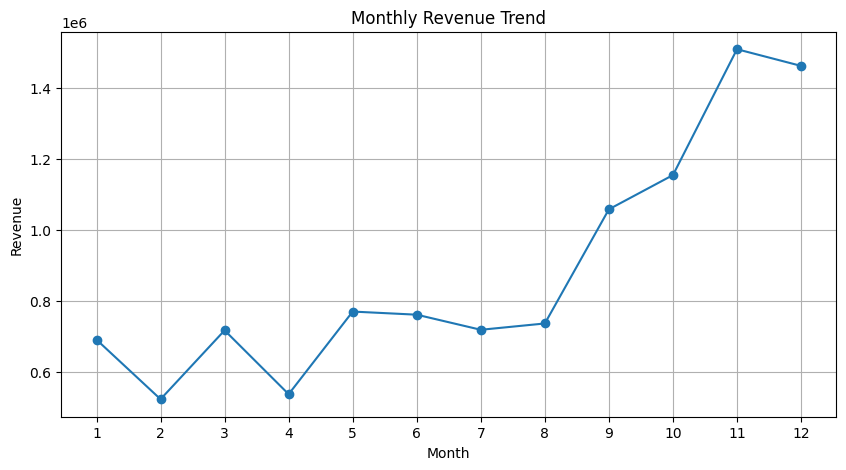

In [ ]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(range(1, 13))
plt.grid(True)
plt.savefig("top_countries_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

Revenue showed an overall upward trend toward the end of the year. November recorded the highest monthly revenue at approximately £1.51 million, followed by December at £1.46 million and October at £1.15 million. This suggests that the business experienced particularly strong sales activity during the final quarter of the year.

In [ ]:
country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

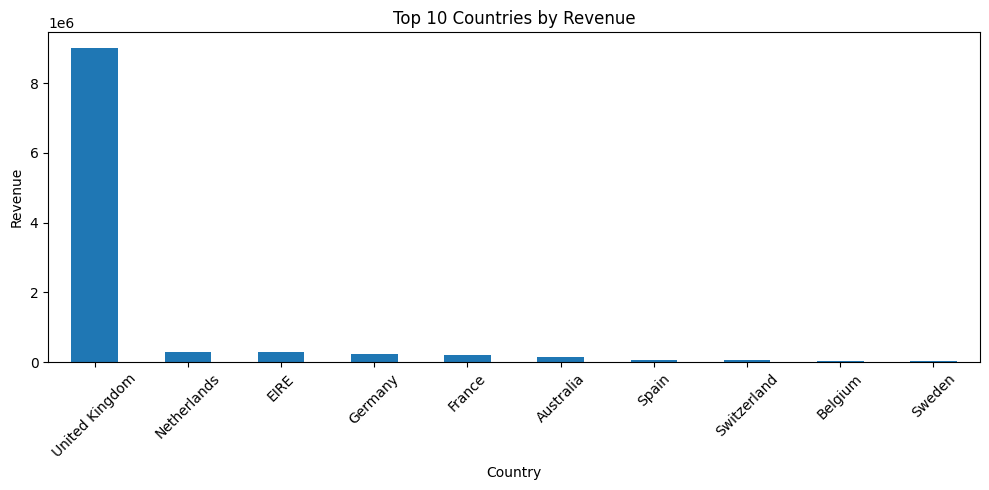

In [ ]:
import matplotlib.pyplot as plt

top_countries = country_revenue.head(10)

top_countries.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_countries_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
product_df = sales_df[
    ~sales_df["Description"].isin(non_products)
].copy()

In [ ]:
product_revenue = (
    product_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

In [ ]:
top_product=product_revenue.head(10)
top_product

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,174484.74
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106292.77
PARTY BUNTING,99504.33
JUMBO BAG RED RETROSPOT,94340.05
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
RABBIT NIGHT LIGHT,66964.99
PAPER CHAIN KIT 50'S CHRISTMAS,64952.29
ASSORTED COLOUR BIRD ORNAMENT,59094.93


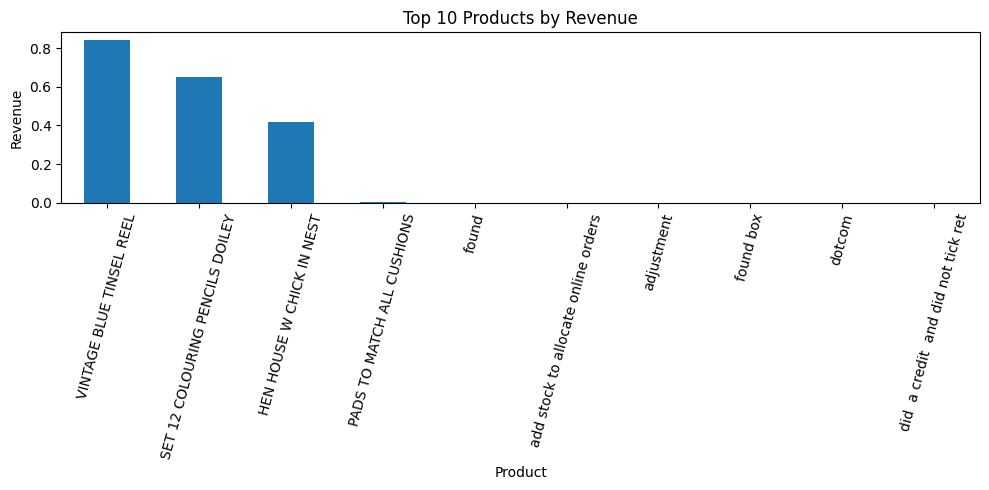

In [ ]:
top_products = product_revenue.head(10)

top_products.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("top_countries_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

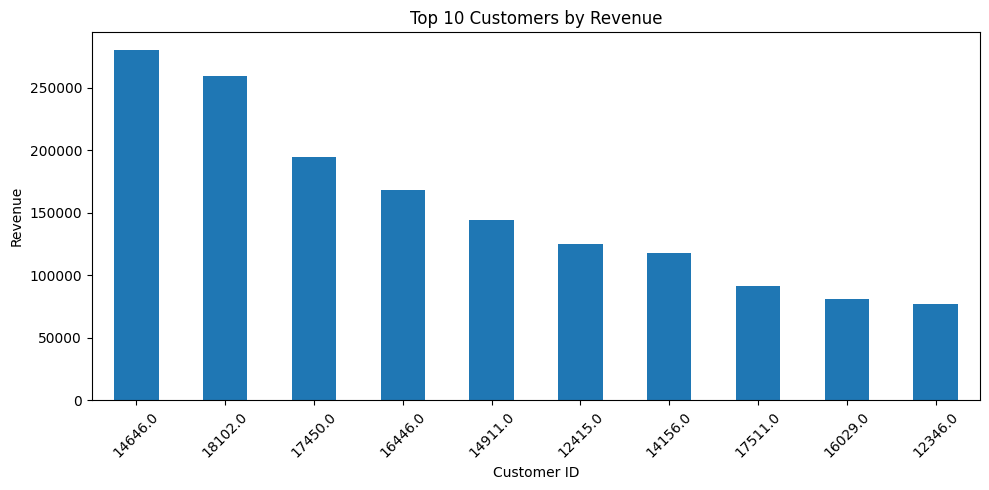

In [ ]:
customer_revenue = (
    sales_df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_customers = customer_revenue.head(10)

top_customers.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_countries_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

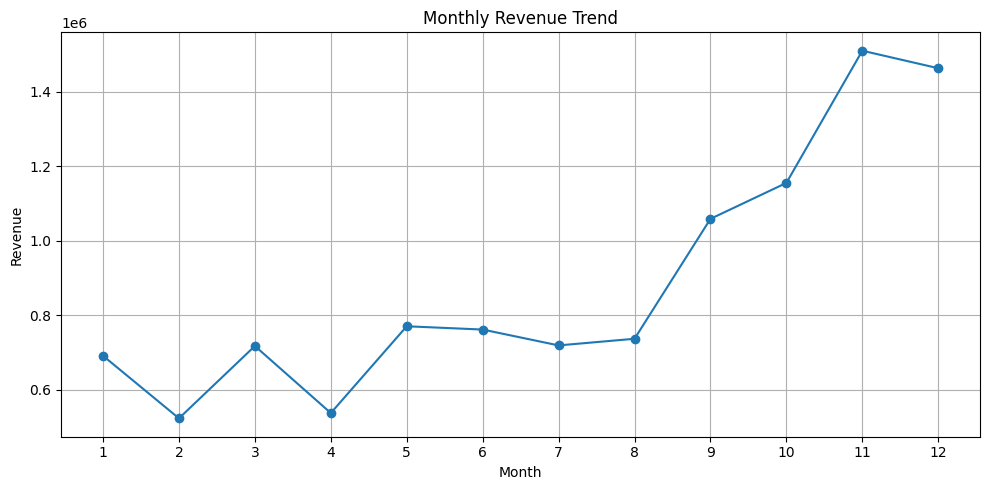

In [ ]:
monthly_revenue.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()
plt.savefig("top_countries_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Recommendations

1. Prioritize customer retention in the UK market while investigating
   opportunities to grow smaller international markets.

2. Develop loyalty incentives and personalized offers for high-value
   customers to encourage repeat purchases.

3. Prepare sufficient inventory, staffing, and marketing campaigns
   ahead of the end-of-year sales period to take advantage of increased
   demand.

4. Investigate the 1,165 zero-price transactions to determine whether
   they represent legitimate free/promotional items or administrative
   and data-entry records.

5. Monitor both product quantity and revenue when evaluating product
   performance, since high sales volume does not necessarily result
   in the highest revenue.

## 11. Conclusion

The analysis identified important patterns in the company's sales
performance, including strong revenue concentration in the UK,
high-value customers, top-performing products, and increased sales
toward the end of the year. These findings can help the business
prioritize customer retention, inventory planning, product evaluation,
and further investigation of unusual transactions.